https://chem.libretexts.org/Ancillary_Materials/Interactive_Applications/Jupyter_Notebooks/Hydrogen_Orbitals_(Python_Notebook)

In [ ]:
import skimage
print(skimage.__version__)

0.25.2


<ipython-input-2-897571023>:14: RuntimeWarning: invalid value encountered in divide
  Theta = numpy.arccos(Z/R)
<ipython-input-2-897571023>:18: DeprecationWarning: `scipy.special.sph_harm` is deprecated as of SciPy 1.15.0 and will be removed in SciPy 1.17.0. Please use `scipy.special.sph_harm_y` instead.
  s_harm=sph_harm(m, l, Phi, Theta)


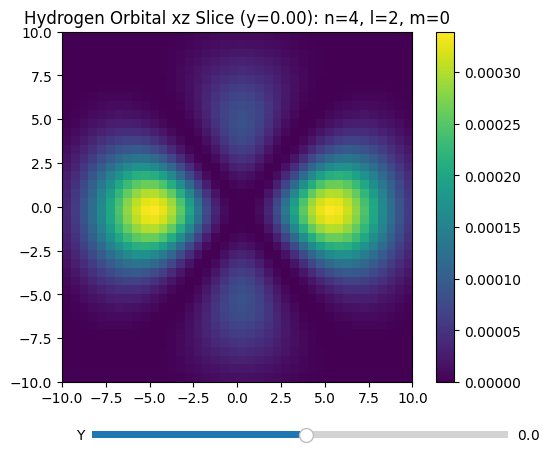

In [ ]:
import numpy
import math
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button, RadioButtons
import scipy.special
from scipy.special import sph_harm
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from matplotlib.colors import ListedColormap
import skimage

def hydrogen_wf(n,l,m,X,Y,Z):
    R = numpy.sqrt(X**2+Y**2+Z**2)
    Theta = numpy.arccos(Z/R)
    Phi = numpy.arctan2(Y,X)

    rho = 2.*R/n
    s_harm=sph_harm(m, l, Phi, Theta)
    l_poly = scipy.special.genlaguerre(n-l-1,2*l+1)(rho)

    prefactor = numpy.sqrt((2./n)**3*math.factorial(n-l-1)/(2.*n*math.factorial(n+l)))
    wf = prefactor*numpy.exp(-rho/2.)*rho**l*s_harm*l_poly
    wf = numpy.nan_to_num(wf)
    return wf

dz=0.5
zmin=-10
zmax=10
x = numpy.arange(zmin,zmax,dz)
y = numpy.arange(zmin,zmax,dz)
z = numpy.arange(zmin,zmax,dz)
X,Y,Z = numpy.meshgrid(x,y,z) #X, Y, Z are 3d arrays that tell us the values of x, y, and z at every point in space

#Change these to change which orbital to plot
n=4
l=2
m=0

data = hydrogen_wf(n,l,m,X,Y,Z)
data = abs(data)**2

R = numpy.sqrt(X**2+Y**2+Z**2)

fig, ax = plt.subplots()
plt.subplots_adjust(left=0.15, bottom=0.15)
im = plt.imshow(data[int((0-zmin)/dz),:,:], vmin=0, vmax = numpy.max(data), extent=[zmin,zmax,zmin,zmax])
plt.colorbar()
sli = Slider(plt.axes([0.25, 0.025, 0.65, 0.03]), "Y", z[0], z[len(z)-1], valinit=0)
ax.set_title("Hydrogen Orbital xz Slice (y="+str("%.2f"%sli.val)+"): n="+str(n)+", l="+str(l)+", m="+str(m))

def update(val):
    index = int((sli.val-zmin) / dz)
    im.set_data(data[index,:,:])
    ax.set_title("Hydrogen Orbital xz Slice (y="+str("%.2f"%sli.val)+"): n="+str(n)+", l="+str(l)+", m="+str(m))

sli.on_changed(update)
plt.show()

<ipython-input-3-3792492577>:15: RuntimeWarning: invalid value encountered in divide
  Theta = numpy.arccos(Z/R)
<ipython-input-3-3792492577>:19: DeprecationWarning: `scipy.special.sph_harm` is deprecated as of SciPy 1.15.0 and will be removed in SciPy 1.17.0. Please use `scipy.special.sph_harm_y` instead.
  s_harm=sph_harm(m, l, Phi, Theta)


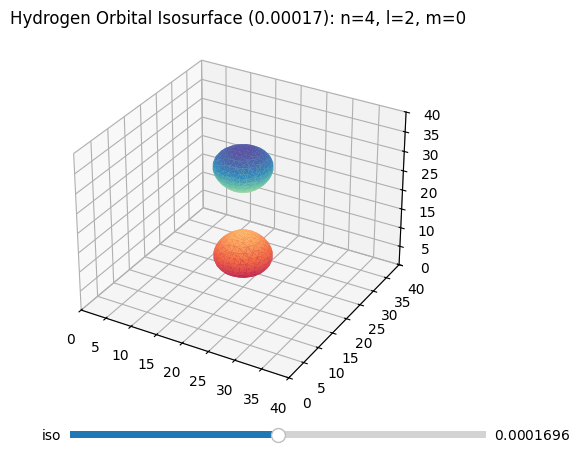

In [ ]:
import numpy
import math
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider, Button, RadioButtons
import scipy.special
from scipy.special import sph_harm
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from matplotlib.colors import ListedColormap
import skimage
from skimage import measure

def hydrogen_wf(n,l,m,X,Y,Z):
    R = numpy.sqrt(X**2+Y**2+Z**2)
    Theta = numpy.arccos(Z/R)
    Phi = numpy.arctan2(Y,X)

    rho = 2.*R/n
    s_harm=sph_harm(m, l, Phi, Theta)
    l_poly = scipy.special.genlaguerre(n-l-1,2*l+1)(rho)

    prefactor = numpy.sqrt((2./n)**3*math.factorial(n-l-1)/(2.*n*math.factorial(n+l)))
    wf = prefactor*numpy.exp(-rho/2.)*rho**l*s_harm*l_poly
    wf = numpy.nan_to_num(wf)
    return wf

dz=0.5
zmin=-10
zmax=10
x = numpy.arange(zmin,zmax,dz)
y = numpy.arange(zmin,zmax,dz)
z = numpy.arange(zmin,zmax,dz)
X,Y,Z = numpy.meshgrid(x,y,z) #X, Y, Z are 3d arrays that tell us the values of x, y, and z at every point in space
n=4
l=2
m=0
data = hydrogen_wf(n,l,m,X,Y,Z)
data = abs(data)**2
R = numpy.sqrt(X**2+Y**2+Z**2)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.set_xlim([0,len(x)])
ax.set_ylim([0,len(y)])
ax.set_zlim([0,len(z)])
max_val = numpy.max(data)

verts, faces, _, _ = measure.marching_cubes(data, max_val/2, spacing = (1,1,1))
result=ax.plot_trisurf(verts[:,0], verts[:,1], faces, verts[:,2], cmap ='Spectral', lw=0)

sli = Slider(plt.axes([0.25, 0.025, 0.65, 0.03]), "iso", 0, max_val, valinit=max_val/2)
ax.set_title("Hydrogen Orbital Isosurface ("+str("%.5f"%sli.val)+"): n="+str(n)+", l="+str(l)+", m="+str(m))

def update(val):
    ax.clear()
    verts, faces = measure.marching_cubes(data, sli.val, spacing = (1,1,1))
    result = ax.plot_trisurf(verts[:,0], verts[:,1], faces, verts[:,2], cmap ='Spectral', lw=0)
    ax.set_xlim([0,len(x)])
    ax.set_ylim([0,len(y)])
    ax.set_zlim([0,len(z)])
    ax.set_title("Hydrogen Orbital Isosurface ("+str("%.5f"%sli.val)+"): n="+str(n)+", l="+str(l)+", m="+str(m))

sli.on_changed(update)
plt.show()

<ipython-input-4-1629550441>:9: RuntimeWarning: invalid value encountered in divide
  Theta = numpy.arccos(Z/R)
<ipython-input-4-1629550441>:13: DeprecationWarning: `scipy.special.sph_harm` is deprecated as of SciPy 1.15.0 and will be removed in SciPy 1.17.0. Please use `scipy.special.sph_harm_y` instead.
  s_harm=sph_harm(m, l, Phi, Theta)


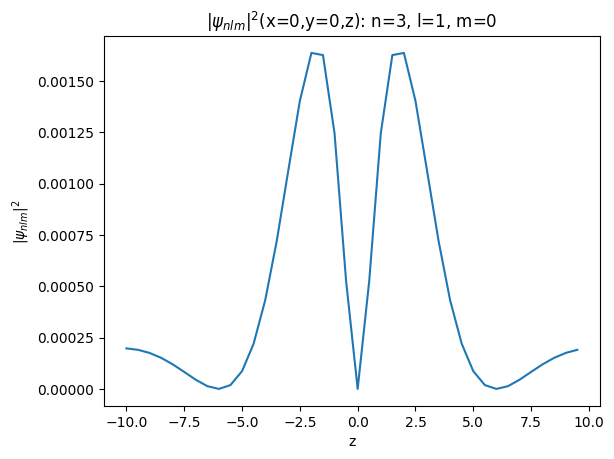

In [ ]:
import numpy
import math
import matplotlib.pyplot as plt
import scipy.special
from scipy.special import sph_harm

def hydrogen_wf(n,l,m,X,Y,Z):
    R = numpy.sqrt(X**2+Y**2+Z**2)
    Theta = numpy.arccos(Z/R)
    Phi = numpy.arctan2(Y,X)

    rho = 2.*R/n
    s_harm=sph_harm(m, l, Phi, Theta)
    l_poly = scipy.special.genlaguerre(n-l-1,2*l+1)(rho)

    prefactor = numpy.sqrt((2./n)**3*math.factorial(n-l-1)/(2.*n*math.factorial(n+l)))
    wf = prefactor*numpy.exp(-rho/2.)*rho**l*s_harm*l_poly
    wf = numpy.nan_to_num(wf)
    return wf

dz=0.5
zmin=-10
zmax=10
x = numpy.arange(zmin,zmax,dz)
y = numpy.arange(zmin,zmax,dz)
z = numpy.arange(zmin,zmax,dz)
X,Y,Z = numpy.meshgrid(x,y,z) #X, Y, Z are 3d arrays that tell us the values of x, y, and z at every point in space
n=3
l=1
m=0
data = hydrogen_wf(n,l,m,X,Y,Z)
data = abs(data)**2
R = numpy.sqrt(X**2+Y**2+Z**2)

plt.figure()
plt.plot(z, data[int(len(z)/2),int(len(z)/2),:])
plt.title("$|\psi_{nlm}|^2$(x=0,y=0,z): n="+str(n)+", l="+str(l)+", m="+str(m))
plt.xlabel('z')
plt.ylabel("$|\psi_{nlm}|^2$")
plt.show()

Hydrogen Atom: Standard Orbitals vs. SQC Dynamic Evolution

--- Generating Standard Plot for Orbital n=2, l=1, m=0 ---


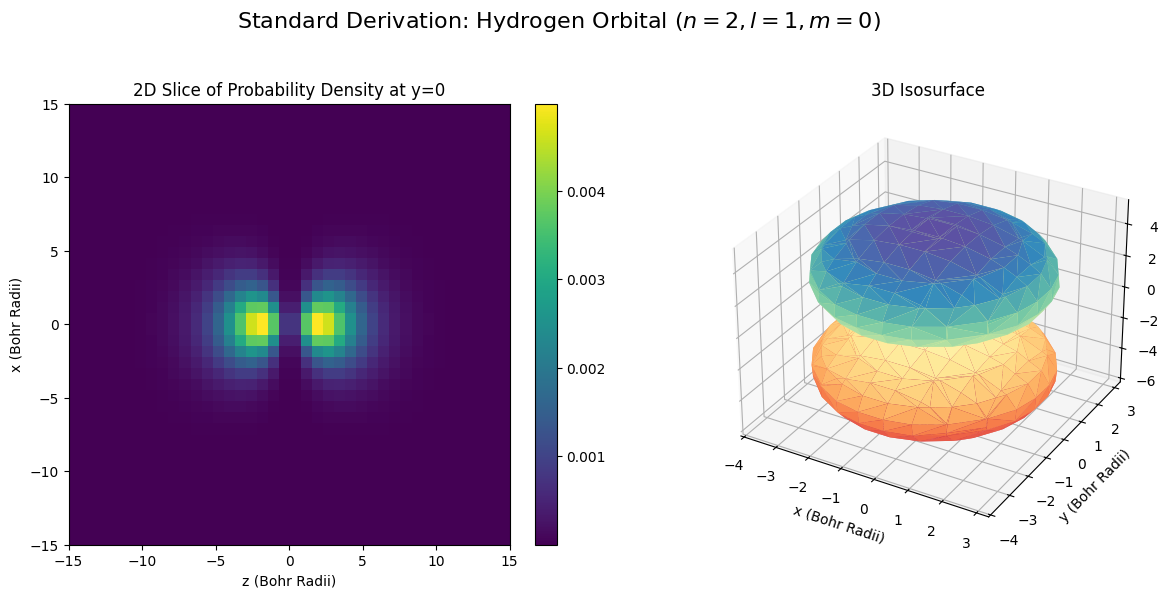


--- Generating Standard Plot for Orbital n=3, l=2, m=1 ---


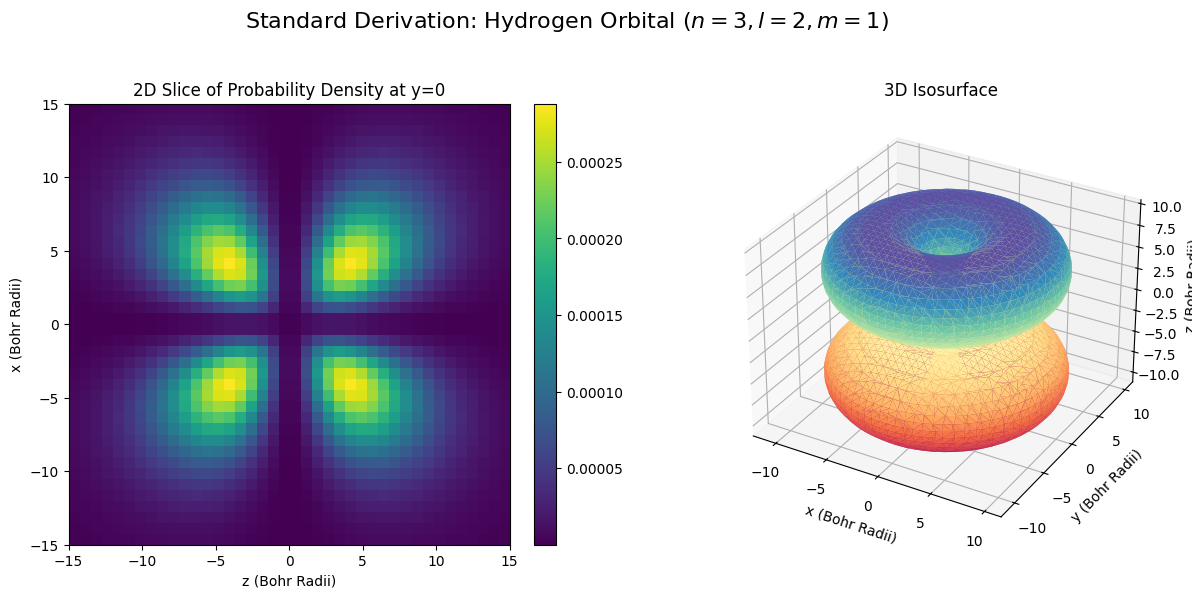


--- Starting SQC Dynamic Evolution (this may take a few minutes)... ---
Calculating evolution for t = 0.1 fs...


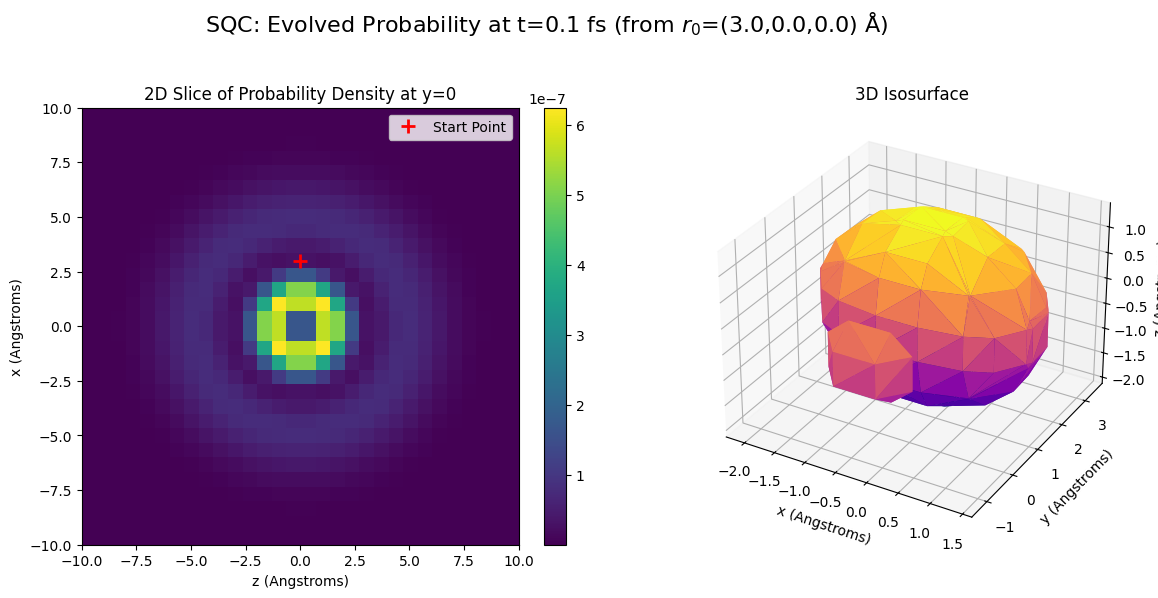

Calculating evolution for t = 0.5 fs...


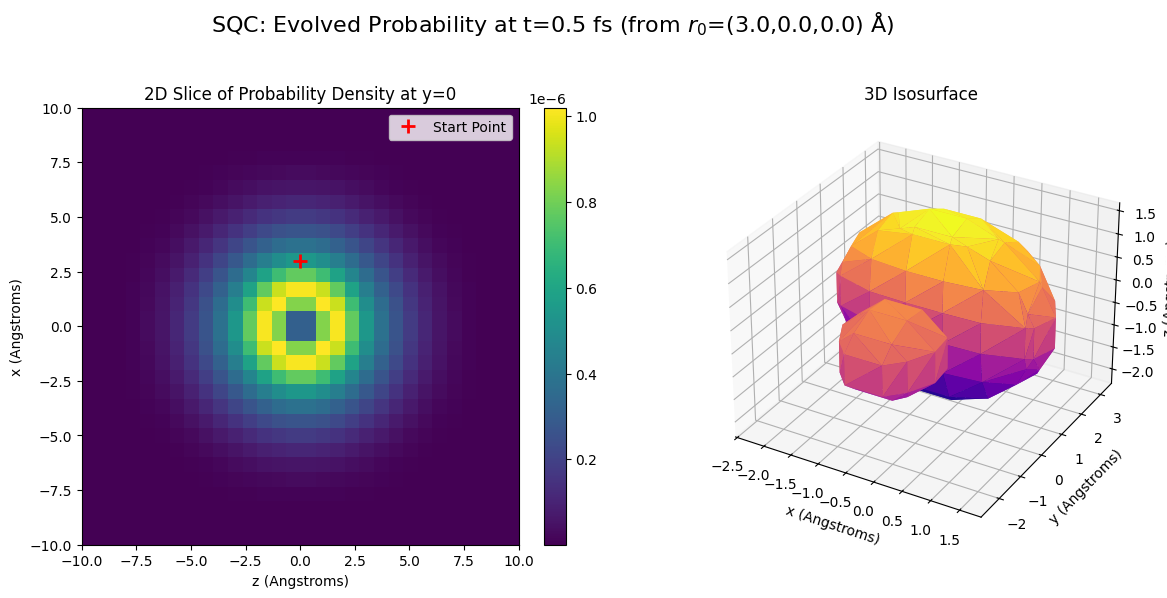


--- All simulations complete. ---


In [ ]:
import numpy as np
import math
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider
import scipy.special
from scipy.special import sph_harm
from mpl_toolkits.mplot3d import Axes3D
from skimage import measure
import warnings

# Ignore common warnings
warnings.filterwarnings('ignore')


# --- Physical Constants ---
H_BAR = 1.054571817e-34  # J*s
RYDBERG_ENERGY = 13.6057  # eV
EV_TO_JOULE = 1.60218e-19 # Conversion factor
BOHR_RADIUS = 0.529      # Angstroms

#======================================================================
# PART 1: CORE CALCULATION FUNCTIONS
#======================================================================

def hydrogen_wf(n, l, m, X, Y, Z, a0=1.0):
    """
    Calculates the hydrogen wavefunction psi_nlm on a 3D grid.
    Distances are scaled by the Bohr radius a0.

    *** THIS FUNCTION HAS BEEN CORRECTED TO HANDLE SCALAR and ARRAY INPUTS. ***
    """
    R = np.sqrt(X**2 + Y**2 + Z**2)

    # --- FIX START: Handle both scalar and array inputs for R ---
    # The original line `R[R == 0] = 1e-9` only worked for arrays.
    # This conditional logic works for both single numbers and arrays.
    if np.isscalar(R):
        if R == 0:
            R = 1e-9
    else:
        R[R == 0] = 1e-9
    # --- FIX END ---

    Theta = np.arccos(Z / R)
    Phi = np.arctan2(Y, X)

    rho = 2. * R / (n * a0)
    s_harm = sph_harm(m, l, Phi, Theta)
    l_poly = scipy.special.genlaguerre(n - l - 1, 2 * l + 1)(rho)

    prefactor = np.sqrt((2. / (n * a0))**3 * math.factorial(n - l - 1) / (2. * n * math.factorial(n + l)))
    wf = prefactor * np.exp(-rho / 2.) * rho**l * s_harm * l_poly

    # Handle potential NaN values at the origin
    wf = np.nan_to_num(wf)
    return wf

def get_energy_eV(n):
    """Returns the energy of the nth shell in eV."""
    return -RYDBERG_ENERGY / n**2

#======================================================================
# PART 2: STANDARD SIMULATION - VISUALIZING ORBITALS
#======================================================================

def plot_hydrogen_orbital(n, l, m, grid_size=40, plot_range_a0=15):
    """
    Generates a 2D slice and a 3D isosurface plot for a given orbital.
    """
    print(f"\n--- Generating Standard Plot for Orbital n={n}, l={l}, m={m} ---")

    # Create the 3D grid, scaled by Bohr radii
    axis_pts = np.linspace(-plot_range_a0, plot_range_a0, grid_size)
    X, Y, Z = np.meshgrid(axis_pts, axis_pts, axis_pts)

    # Calculate probability density
    wf_data = hydrogen_wf(n, l, m, X, Y, Z)
    prob_density = np.abs(wf_data)**2

    # --- Plotting ---
    fig = plt.figure(figsize=(14, 6))
    title = f'Standard Derivation: Hydrogen Orbital ($n={n}, l={l}, m={m}$)'
    fig.suptitle(title, fontsize=16)

    # 1. 2D Slice in the x-z plane (at y=0)
    ax1 = fig.add_subplot(1, 2, 1)
    slice_index = grid_size // 2
    im = ax1.imshow(
        prob_density[:, slice_index, :],
        extent=[-plot_range_a0, plot_range_a0, -plot_range_a0, plot_range_a0],
        origin='lower', cmap='viridis'
    )
    ax1.set_title('2D Slice of Probability Density at y=0')
    ax1.set_xlabel('z (Bohr Radii)')
    ax1.set_ylabel('x (Bohr Radii)')
    fig.colorbar(im, ax=ax1, fraction=0.046, pad=0.04)

    # 2. 3D Isosurface
    ax2 = fig.add_subplot(1, 2, 2, projection='3d')
    max_val = np.max(prob_density)
    iso_val = max_val * 0.2  # Choose an isosurface value

    try:
        verts, faces, _, _ = measure.marching_cubes(prob_density, iso_val)
        # Scale vertices back to Bohr radii coordinates
        verts_scaled = verts * (2 * plot_range_a0 / grid_size) - plot_range_a0
        ax2.plot_trisurf(verts_scaled[:, 0], verts_scaled[:, 1], faces, verts_scaled[:, 2], cmap='Spectral', lw=0)
    except (ValueError, RuntimeError):
        ax2.text2D(0.5, 0.5, "Isosurface not found\nat this level", ha='center', va='center', transform=ax2.transAxes)

    ax2.set_title(f'3D Isosurface')
    ax2.set_xlabel('x (Bohr Radii)')
    ax2.set_ylabel('y (Bohr Radii)')
    ax2.set_zlabel('z (Bohr Radii)')

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

#======================================================================
# PART 3: SQC SIMULATION - DYNAMIC EVOLUTION
#======================================================================

def calculate_hydrogen_propagator(r0_A, t_sec, X, Y, Z, n_max):
    """
    Calculates the propagator U(r, r0, t) for an electron starting at r0.
    This is the time-evolved wavefunction from an initial delta-function state.
    """
    # Convert grid from Angstroms to Bohr Radii for wavefunction calculation
    a0 = BOHR_RADIUS
    X_a0, Y_a0, Z_a0 = X / a0, Y / a0, Z / a0

    propagator = np.zeros_like(X, dtype=complex)

    # Convert starting position to Bohr Radii
    r0_a0 = r0_A / a0

    # Sum over all eigenstates up to n_max
    for n in range(1, n_max + 1):
        E_n_joule = get_energy_eV(n) * EV_TO_JOULE
        time_factor = np.exp(-1j * E_n_joule * t_sec / H_BAR)

        # Sum over degenerate l and m states for this shell
        for l in range(n):
            for m in range(-l, l + 1):
                psi_r = hydrogen_wf(n, l, m, X_a0, Y_a0, Z_a0)
                psi_r0_conj = np.conjugate(hydrogen_wf(n, l, m, r0_a0[0], r0_a0[1], r0_a0[2]))
                propagator += time_factor * psi_r * psi_r0_conj

    return propagator

def plot_sqc_evolution(prob_density_3d, t_fs, r0_A, grid_range_A):
    """
    Plots the evolved 3D probability density from the SQC simulation.
    """
    fig = plt.figure(figsize=(14, 6))
    title = f'SQC: Evolved Probability at t={t_fs:.1f} fs (from $r_0$=({r0_A[0]},{r0_A[1]},{r0_A[2]}) Å)'
    fig.suptitle(title, fontsize=16)

    grid_size = prob_density_3d.shape[0]

    # 1. 2D Slice
    ax1 = fig.add_subplot(1, 2, 1)
    slice_index = grid_size // 2
    im = ax1.imshow(
        prob_density_3d[:, slice_index, :],
        extent=[-grid_range_A, grid_range_A, -grid_range_A, grid_range_A],
        origin='lower', cmap='viridis'
    )
    ax1.set_title('2D Slice of Probability Density at y=0')
    ax1.set_xlabel('z (Angstroms)')
    ax1.set_ylabel('x (Angstroms)')
    ax1.plot(r0_A[2], r0_A[0], 'r+', ms=10, markeredgewidth=2, label='Start Point') # Mark start point
    ax1.legend()
    fig.colorbar(im, ax=ax1, fraction=0.046, pad=0.04)

    # 2. 3D Isosurface
    ax2 = fig.add_subplot(1, 2, 2, projection='3d')
    max_val = np.max(prob_density_3d)
    iso_val = max_val * 0.3 # Choose an isosurface value

    try:
        verts, faces, _, _ = measure.marching_cubes(prob_density_3d, iso_val)
        verts_scaled = verts * (2 * grid_range_A / grid_size) - grid_range_A
        ax2.plot_trisurf(verts_scaled[:, 0], verts_scaled[:, 1], faces, verts_scaled[:, 2], cmap='plasma', lw=0)
    except (ValueError, RuntimeError):
        ax2.text2D(0.5, 0.5, "Isosurface not found\nat this level", ha='center', va='center', transform=ax2.transAxes)

    ax2.set_title(f'3D Isosurface')
    ax2.set_xlabel('x (Angstroms)')
    ax2.set_ylabel('y (Angstroms)')
    ax2.set_zlabel('z (Angstroms)')

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

#======================================================================
# MAIN EXECUTION BLOCK
#======================================================================

if __name__ == "__main__":
    print("Hydrogen Atom: Standard Orbitals vs. SQC Dynamic Evolution")
    print("="*60)

    # --- Standard Simulation: Plot a few familiar orbitals ---
    plot_hydrogen_orbital(n=2, l=1, m=0)  # 2pz orbital
    plot_hydrogen_orbital(n=3, l=2, m=1)  # A 3d orbital

    # --- SQC Simulation: Evolve a localized electron over time ---
    print("\n--- Starting SQC Dynamic Evolution (this may take a few minutes)... ---")

    # Simulation parameters
    GRID_RANGE_A = 10  # Plot from -10 to +10 Angstroms
    GRID_SIZE = 30     # Use a coarser grid to speed up calculation
    N_MAX_SUM = 4      # Sum up to n=4 shell. Higher is more accurate but much slower.

    # Define the 3D grid in Angstroms
    axis_pts = np.linspace(-GRID_RANGE_A, GRID_RANGE_A, GRID_SIZE)
    X, Y, Z = np.meshgrid(axis_pts, axis_pts, axis_pts)

    # Initial position of the electron (in Angstroms)
    r0_angstrom = np.array([3.0, 0.0, 0.0])

    # Time points for evolution
    time_points_fs = [0.1, 0.5] # Femtoseconds

    for t_fs in time_points_fs:
        print(f"Calculating evolution for t = {t_fs} fs...")
        t_sec = t_fs * 1e-15

        # Calculate the evolved wavefunction (the propagator)
        propagator = calculate_hydrogen_propagator(r0_angstrom, t_sec, X, Y, Z, N_MAX_SUM)

        # The evolved probability density is the squared modulus
        evolved_prob_density = np.abs(propagator)**2

        # Plot the result
        plot_sqc_evolution(evolved_prob_density, t_fs, r0_angstrom, GRID_RANGE_A)

    print("\n--- All simulations complete. ---")